# Optuna를 활용한 고급 하이퍼파라미터 최적화

## 개요
- Pima Indians Diabetes 데이터셋으로 **당뇨병 발병 여부** 예측
- **Optuna**: 베이지안 최적화 기반의 차세대 하이퍼파라미터 튜닝 프레임워크
- **3가지 Gradient Boosting 모델** 최적화: XGBoost, LightGBM, CatBoost
- Optuna vs GridSearch vs RandomSearch 성능 비교

## Optuna의 장점
- 🚀 **효율적인 탐색**: TPE(Tree-structured Parzen Estimator) 알고리즘 사용
- 📊 **시각화**: 최적화 과정 실시간 모니터링
- ⚡ **조기 종료**: Pruning으로 불필요한 시도 자동 중단
- 🎯 **유연성**: 조건부 파라미터 탐색 가능

## 주요 단계
1. 데이터 로드 및 분리
2. Optuna 기본 사용법
3. 각 모델별 Optuna 최적화
4. 최적화 과정 시각화
5. 다른 방법과 비교 분석

## 라이브러리 설치 및 임포트

In [1]:
# 필요한 라이브러리 설치
!pip install optuna catboost koreanize-matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 7.9 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns
import warnings
import time
warnings.filterwarnings('ignore')

# Optuna
import optuna
from optuna import Trial
from optuna.visualization import (
    plot_optimization_history,
    plot_param_importances,
    plot_slice,
    plot_contour
)

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Optuna 로깅 레벨 조정
optuna.logging.set_verbosity(optuna.logging.WARNING)

# 랜덤 시드 고정
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print(f"Optuna 버전: {optuna.__version__}")

✅ 라이브러리 임포트 완료!
Optuna 버전: 4.6.0


## 1. 데이터 로드

**Pima Indians Diabetes 데이터셋**
- 768개 샘플, 8개 피처
- 당뇨병 발병 여부 이진 분류
- 피처: 임신 횟수, 혈당, 혈압, 피부두께, 인슐린, BMI, 당뇨병 가족력, 나이

In [3]:
print("Loading Pima Indians Diabetes Dataset...")
pima = fetch_openml(name='diabetes', version=1, as_frame=True)
X = pima.data
y = pima.target.map({'tested_negative': 0, 'tested_positive': 1}).astype(int)

print(f"데이터 크기: {X.shape}")
print(f"피처 목록: {list(X.columns)}")
print(f"\n클래스 분포:\n{y.value_counts()}")
print(f"\n클래스 비율:\n{y.value_counts(normalize=True).round(3)}")

Loading Pima Indians Diabetes Dataset...
데이터 크기: (768, 8)
피처 목록: ['preg', 'plas', 'pres', 'skin', 'insu', 'mass', 'pedi', 'age']

클래스 분포:
class
0    500
1    268
Name: count, dtype: int64

클래스 비율:
class
0    0.651
1    0.349
Name: proportion, dtype: float64


**데이터 샘플 확인**

In [4]:
print("\n데이터 샘플:")
print(X.head())

print("\n기술 통계:")
print(X.describe())


데이터 샘플:
   preg  plas  pres  skin  insu  mass   pedi  age
0     6   148    72    35     0  33.6  0.627   50
1     1    85    66    29     0  26.6  0.351   31
2     8   183    64     0     0  23.3  0.672   32
3     1    89    66    23    94  28.1  0.167   21
4     0   137    40    35   168  43.1  2.288   33

결측치 확인:
결측치: 0개

기술 통계:
             preg        plas        pres        skin        insu        mass  \
count  768.000000  768.000000  768.000000  768.000000  768.000000  768.000000   
mean     3.845052  120.894531   69.105469   20.536458   79.799479   31.992578   
std      3.369578   31.972618   19.355807   15.952218  115.244002    7.884160   
min      0.000000    0.000000    0.000000    0.000000    0.000000    0.000000   
25%      1.000000   99.000000   62.000000    0.000000    0.000000   27.300000   
50%      3.000000  117.000000   72.000000   23.000000   30.500000   32.000000   
75%      6.000000  140.250000   80.000000   32.000000  127.250000   36.600000   
max     17.000000 

**학습/테스트 데이터 분리**

In [5]:
# 데이터 분할 (stratify로 클래스 비율 유지)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"\nTrain 클래스 분포:\n{y_train.value_counts()}")

Train: (614, 8), Test: (154, 8)

Train 클래스 분포:
class
0    400
1    214
Name: count, dtype: int64


---
## 2. Optuna 기본 사용법

**Optuna 핵심 개념**
- Study: 최적화 세션 (하나의 최적화 작업)
- Trial: 하이퍼파라미터 조합 하나의 시도
- Objective Function: 최적화할 목표 함수
- Sampler: 파라미터 탐색 알고리즘 (기본: TPE)

간단한 예제로 Optuna의 기본 개념을 이해합니다.

In [6]:
print("\n" + "="*60)
print("Optuna 기본 예제: XGBoost 간단 최적화")
print("="*60)

def objective_simple(trial):
    """
    Optuna 목적 함수 (Objective Function)
    - trial: Optuna가 제공하는 하이퍼파라미터 제안 객체
    - 반환값: 최대화 또는 최소화할 지표
    """

    # 하이퍼파라미터 제안
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 200),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'random_state': RANDOM_STATE,
        'eval_metric': 'logloss',
        'use_label_encoder': False
    }

    # 모델 생성 및 평가
    model = XGBClassifier(**params)

    # 교차 검증 점수 (최대화할 지표)
    cv_score = cross_val_score(
        model, X_train, y_train,
        cv=3, scoring='accuracy', n_jobs=-1
    ).mean()

    return cv_score

# Optuna Study 생성 (최대화 목표)
study_simple = optuna.create_study(
    direction='maximize',  # 점수를 최대화
    study_name='xgboost_simple'
)

# 최적화 실행 (20회 시도)
print("\n최적화 시작 (20회 시도)...")
study_simple.optimize(objective_simple, n_trials=20, show_progress_bar=True)

# 결과 출력
print(f"최고 정확도: {study_simple.best_value:.4f}")
print(f"\n최적 하이퍼파라미터:")
for param, value in study_simple.best_params.items():
    print(f"  {param}: {value}")


Optuna 기본 예제: XGBoost 간단 최적화

최적화 시작 (20회 시도)...


  0%|          | 0/20 [00:00<?, ?it/s]


✅ 최적화 완료!
최고 정확도: 0.7672

최적 하이퍼파라미터:
  n_estimators: 95
  max_depth: 9
  learning_rate: 0.0326372896947509


## 3. 모델별 Optuna 최적화

**최적화 전략**
- 각 모델의 특성에 맞는 파라미터 범위 설정
- 교차 검증으로 안정적인 평가
- 충분한 시도 횟수 (50-100회)

**파라미터 탐색 공간**
- suggest_int: 정수형 파라미터
- suggest_float: 실수형 파라미터
- suggest_categorical: 범주형 파라미터

### 3.1 XGBoost 최적화

In [8]:
print("\n" + "="*60)
print("XGBoost Optuna 최적화")
print("="*60)

def objective_xgboost(trial):
    # 하이퍼파라미터 탐색 공간 정의
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0, 0.5),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 1),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 1),
        'random_state': RANDOM_STATE,
        'eval_metric': 'logloss',
        'use_label_encoder': False
    }

    model = XGBClassifier(**params)
    cv_score = cross_val_score(
        model, X_train, y_train,
        cv=5, scoring='accuracy', n_jobs=-1
    ).mean()

    return cv_score

# Study 생성 및 최적화
study_xgb = optuna.create_study(
    direction='maximize',
    study_name='xgboost_full'
)

print("\n최적화 시작 (50회 시도)...")
start_time = time.time()
study_xgb.optimize(objective_xgboost, n_trials=50, show_progress_bar=True)
xgb_time = time.time() - start_time

print(f"\n XGBoost 최적화 완료! (소요 시간: {xgb_time:.2f}초)")
print(f"최고 CV 점수: {study_xgb.best_value:.4f}")
print(f"\n최적 하이퍼파라미터:")
for param, value in study_xgb.best_params.items():
    print(f"  {param}: {value}")


XGBoost Optuna 최적화

최적화 시작 (50회 시도)...


  0%|          | 0/50 [00:00<?, ?it/s]


✅ XGBoost 최적화 완료! (소요 시간: 16.67초)
최고 CV 점수: 0.7769

최적 하이퍼파라미터:
  n_estimators: 196
  max_depth: 11
  learning_rate: 0.016661386924829494
  subsample: 0.7921670781723319
  colsample_bytree: 0.7132234231037142
  min_child_weight: 9
  gamma: 0.4011336780299265
  reg_alpha: 0.2946393237313032
  reg_lambda: 0.483299214030218


### 3.2 LightGBM 최적화

In [9]:
print("\n" + "="*60)
print("LightGBM Optuna 최적화")
print("="*60)

def objective_lgbm(trial):
    # 하이퍼파라미터 탐색 공간 정의
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 1),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 1),
        'random_state': RANDOM_STATE,
        'verbose': -1
    }

    model = LGBMClassifier(**params)
    cv_score = cross_val_score(
        model, X_train, y_train,
        cv=5, scoring='accuracy', n_jobs=-1
    ).mean()

    return cv_score

# Study 생성 및 최적화
study_lgbm = optuna.create_study(
    direction='maximize',
    study_name='lightgbm_full'
)

print("\n최적화 시작 (50회 시도)...")
start_time = time.time()
study_lgbm.optimize(objective_lgbm, n_trials=50, show_progress_bar=True)
lgbm_time = time.time() - start_time

print(f"\n LightGBM 최적화 완료! (소요 시간: {lgbm_time:.2f}초)")
print(f"최고 CV 점수: {study_lgbm.best_value:.4f}")
print(f"\n최적 하이퍼파라미터:")
for param, value in study_lgbm.best_params.items():
    print(f"  {param}: {value}")


LightGBM Optuna 최적화

최적화 시작 (50회 시도)...


  0%|          | 0/50 [00:00<?, ?it/s]


✅ LightGBM 최적화 완료! (소요 시간: 15.46초)
최고 CV 점수: 0.7867

최적 하이퍼파라미터:
  n_estimators: 199
  learning_rate: 0.015645592146466398
  num_leaves: 39
  max_depth: 15
  min_child_samples: 43
  subsample: 0.9968431153054436
  colsample_bytree: 0.9645518568683039
  reg_alpha: 0.7130026101920918
  reg_lambda: 0.47576845813515173


### 3.3 CatBoost 최적화

In [10]:
print("\n" + "="*60)
print("CatBoost Optuna 최적화")
print("="*60)

def objective_catboost(trial):
    # 하이퍼파라미터 탐색 공간 정의
    params = {
        'iterations': trial.suggest_int('iterations', 50, 300),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'depth': trial.suggest_int('depth', 3, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'border_count': trial.suggest_int('border_count', 32, 255),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0, 1),
        'random_strength': trial.suggest_float('random_strength', 0, 10),
        'random_state': RANDOM_STATE,
        'verbose': 0
    }

    model = CatBoostClassifier(**params)
    cv_score = cross_val_score(
        model, X_train, y_train,
        cv=5, scoring='accuracy', n_jobs=-1
    ).mean()

    return cv_score

# Study 생성 및 최적화
study_cat = optuna.create_study(
    direction='maximize',
    study_name='catboost_full'
)

print("\n최적화 시작 (50회 시도)...")
start_time = time.time()
study_cat.optimize(objective_catboost, n_trials=50, show_progress_bar=True)
cat_time = time.time() - start_time

print(f"\n CatBoost 최적화 완료! (소요 시간: {cat_time:.2f}초)")
print(f"최고 CV 점수: {study_cat.best_value:.4f}")
print(f"\n최적 하이퍼파라미터:")
for param, value in study_cat.best_params.items():
    print(f"  {param}: {value}")


CatBoost Optuna 최적화

최적화 시작 (50회 시도)...


  0%|          | 0/50 [00:00<?, ?it/s]


✅ CatBoost 최적화 완료! (소요 시간: 97.08초)
최고 CV 점수: 0.7834

최적 하이퍼파라미터:
  iterations: 178
  learning_rate: 0.03224606668516516
  depth: 4
  l2_leaf_reg: 1.915694377445651
  border_count: 61
  bagging_temperature: 0.3944688517105687
  random_strength: 1.5398841505664589


## 4. 최적화 과정 시각화

**Optuna 시각화 도구**
- plot_optimization_history: 시도별 성능 변화
- plot_param_importances: 파라미터 중요도
- plot_slice: 파라미터별 성능 분포
- plot_contour: 파라미터 간 상호작용

### 4.1 최적화 히스토리

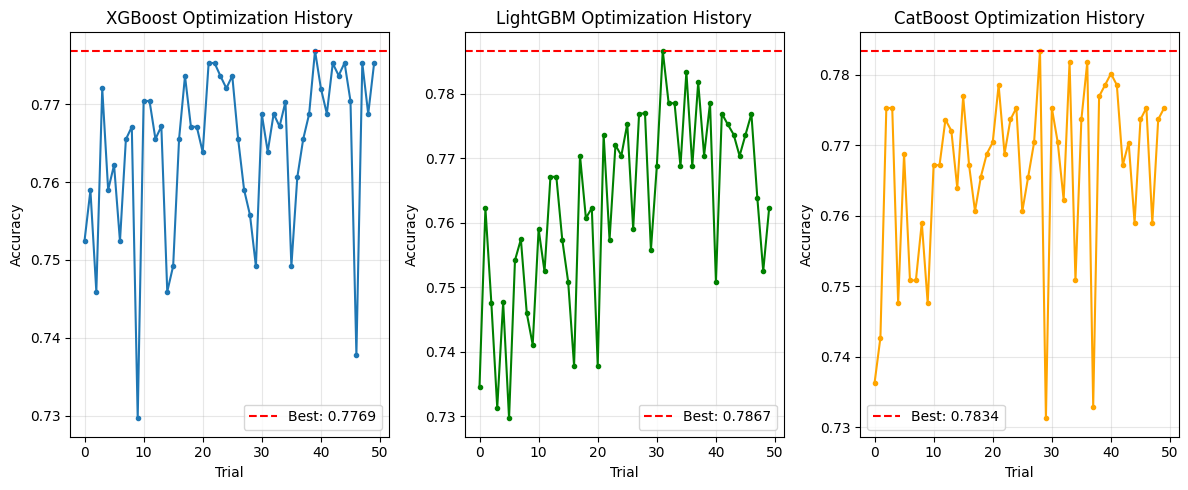

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(12, 5))

# XGBoost
study_data = study_xgb.trials_dataframe()
axes[0].plot(study_data['number'], study_data['value'], marker='o', markersize=3)
axes[0].axhline(y=study_xgb.best_value, color='r', linestyle='--', label=f'Best: {study_xgb.best_value:.4f}')
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('XGBoost Optimization History')
axes[0].legend()
axes[0].grid(alpha=0.3)

# LightGBM
study_data = study_lgbm.trials_dataframe()
axes[1].plot(study_data['number'], study_data['value'], marker='o', markersize=3, color='green')
axes[1].axhline(y=study_lgbm.best_value, color='r', linestyle='--', label=f'Best: {study_lgbm.best_value:.4f}')
axes[1].set_xlabel('Trial')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('LightGBM Optimization History')
axes[1].legend()
axes[1].grid(alpha=0.3)

# CatBoost
study_data = study_cat.trials_dataframe()
axes[2].plot(study_data['number'], study_data['value'], marker='o', markersize=3, color='orange')
axes[2].axhline(y=study_cat.best_value, color='r', linestyle='--', label=f'Best: {study_cat.best_value:.4f}')
axes[2].set_xlabel('Trial')
axes[2].set_ylabel('Accuracy')
axes[2].set_title('CatBoost Optimization History')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 4.2 파라미터 중요도

In [12]:
# XGBoost 파라미터 중요도
fig = plot_param_importances(study_xgb)
fig.update_layout(title="XGBoost - Parameter Importances", height=500)
fig.show()

# LightGBM 파라미터 중요도
fig = plot_param_importances(study_lgbm)
fig.update_layout(title="LightGBM - Parameter Importances", height=500)
fig.show()

# CatBoost 파라미터 중요도
fig = plot_param_importances(study_cat)
fig.update_layout(title="CatBoost - Parameter Importances", height=500)
fig.show()

## 5. 최종 평가 및 비교

**비교 대상**
1. Optuna 최적화 결과
2. GridSearchCV (제한적 범위)
3. RandomizedSearchCV (동일 시도 횟수)
4. 기본 설정 (Baseline)

### 5.1 Optuna 최적 모델 테스트

In [14]:
print("\n" + "="*80)
print("Optuna 최적 모델 테스트 세트 평가")
print("="*80)

optuna_results = []

# XGBoost
xgb_best = XGBClassifier(**study_xgb.best_params, random_state=RANDOM_STATE,
                          eval_metric='logloss', use_label_encoder=False)
xgb_best.fit(X_train, y_train)
y_pred_xgb = xgb_best.predict(X_test)
xgb_acc = accuracy_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb, average='weighted')

optuna_results.append({
    'Model': 'XGBoost',
    'Method': 'Optuna',
    'CV Score': study_xgb.best_value,
    'Test Accuracy': xgb_acc,
    'Test F1': xgb_f1,
    'Time': xgb_time
})

print(f"\nXGBoost - Test Accuracy: {xgb_acc:.4f}, F1: {xgb_f1:.4f}")

# LightGBM
lgbm_best = LGBMClassifier(**study_lgbm.best_params, random_state=RANDOM_STATE, verbose=-1)
lgbm_best.fit(X_train, y_train)
y_pred_lgbm = lgbm_best.predict(X_test)
lgbm_acc = accuracy_score(y_test, y_pred_lgbm)
lgbm_f1 = f1_score(y_test, y_pred_lgbm, average='weighted')

optuna_results.append({
    'Model': 'LightGBM',
    'Method': 'Optuna',
    'CV Score': study_lgbm.best_value,
    'Test Accuracy': lgbm_acc,
    'Test F1': lgbm_f1,
    'Time': lgbm_time
})

print(f"LightGBM - Test Accuracy: {lgbm_acc:.4f}, F1: {lgbm_f1:.4f}")

# CatBoost
cat_best = CatBoostClassifier(**study_cat.best_params, random_state=RANDOM_STATE, verbose=0)
cat_best.fit(X_train, y_train)
y_pred_cat = cat_best.predict(X_test)
cat_acc = accuracy_score(y_test, y_pred_cat)
cat_f1 = f1_score(y_test, y_pred_cat, average='weighted')

optuna_results.append({
    'Model': 'CatBoost',
    'Method': 'Optuna',
    'CV Score': study_cat.best_value,
    'Test Accuracy': cat_acc,
    'Test F1': cat_f1,
    'Time': cat_time
})

print(f"CatBoost - Test Accuracy: {cat_acc:.4f}, F1: {cat_f1:.4f}")

optuna_df = pd.DataFrame(optuna_results)
print("\n" + "="*80)
print(optuna_df.to_string(index=False))


Optuna 최적 모델 테스트 세트 평가

XGBoost - Test Accuracy: 0.7662, F1: 0.7614
LightGBM - Test Accuracy: 0.7662, F1: 0.7599
CatBoost - Test Accuracy: 0.7403, F1: 0.7332

   Model Method  CV Score  Test Accuracy  Test F1      Time
 XGBoost Optuna  0.776863       0.766234 0.761379 16.667108
LightGBM Optuna  0.786659       0.766234 0.759873 15.456079
CatBoost Optuna  0.783407       0.740260 0.733192 97.076396


### 5.2 GridSearchCV 비교

In [15]:
print("\n" + "="*80)
print("GridSearchCV 비교 (제한적 범위)")
print("="*80)

grid_results = []

# XGBoost GridSearch
param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1]
}

print("\nXGBoost GridSearch...")
start_time = time.time()
grid_xgb = GridSearchCV(
    XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss', use_label_encoder=False),
    param_grid_xgb, cv=5, scoring='accuracy', n_jobs=-1, verbose=0
)
grid_xgb.fit(X_train, y_train)
grid_xgb_time = time.time() - start_time

y_pred = grid_xgb.predict(X_test)
grid_results.append({
    'Model': 'XGBoost',
    'Method': 'GridSearch',
    'CV Score': grid_xgb.best_score_,
    'Test Accuracy': accuracy_score(y_test, y_pred),
    'Test F1': f1_score(y_test, y_pred, average='weighted'),
    'Time': grid_xgb_time
})

# LightGBM GridSearch
param_grid_lgbm = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'num_leaves': [31, 50]
}

print("LightGBM GridSearch...")
start_time = time.time()
grid_lgbm = GridSearchCV(
    LGBMClassifier(random_state=RANDOM_STATE, verbose=-1),
    param_grid_lgbm, cv=5, scoring='accuracy', n_jobs=-1, verbose=0
)
grid_lgbm.fit(X_train, y_train)
grid_lgbm_time = time.time() - start_time

y_pred = grid_lgbm.predict(X_test)
grid_results.append({
    'Model': 'LightGBM',
    'Method': 'GridSearch',
    'CV Score': grid_lgbm.best_score_,
    'Test Accuracy': accuracy_score(y_test, y_pred),
    'Test F1': f1_score(y_test, y_pred, average='weighted'),
    'Time': grid_lgbm_time
})

# CatBoost GridSearch
param_grid_cat = {
    'iterations': [100, 200],
    'learning_rate': [0.01, 0.1],
    'depth': [4, 6]
}

print("CatBoost GridSearch...")
start_time = time.time()
grid_cat = GridSearchCV(
    CatBoostClassifier(random_state=RANDOM_STATE, verbose=0),
    param_grid_cat, cv=5, scoring='accuracy', n_jobs=-1, verbose=0
)
grid_cat.fit(X_train, y_train)
grid_cat_time = time.time() - start_time

y_pred = grid_cat.predict(X_test)
grid_results.append({
    'Model': 'CatBoost',
    'Method': 'GridSearch',
    'CV Score': grid_cat.best_score_,
    'Test Accuracy': accuracy_score(y_test, y_pred),
    'Test F1': f1_score(y_test, y_pred, average='weighted'),
    'Time': grid_cat_time
})

grid_df = pd.DataFrame(grid_results)
print("\n" + "="*80)
print(grid_df.to_string(index=False))


GridSearchCV 비교 (제한적 범위)

XGBoost GridSearch...
LightGBM GridSearch...
CatBoost GridSearch...

   Model     Method  CV Score  Test Accuracy  Test F1     Time
 XGBoost GridSearch  0.759043       0.746753 0.740695 6.441094
LightGBM GridSearch  0.763908       0.733766 0.721583 1.987350
CatBoost GridSearch  0.776929       0.740260 0.729414 9.227991


### 5.3 RandomizedSearchCV 비교

In [16]:
print("\n" + "="*80)
print("RandomizedSearchCV 비교 (50회 시도)")
print("="*80)

random_results = []

# XGBoost RandomSearch
param_dist_xgb = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [3, 5, 7, 10, 15],
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

print("\nXGBoost RandomSearch...")
start_time = time.time()
random_xgb = RandomizedSearchCV(
    XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss', use_label_encoder=False),
    param_dist_xgb, n_iter=50, cv=5, scoring='accuracy',
    n_jobs=-1, random_state=RANDOM_STATE, verbose=0
)
random_xgb.fit(X_train, y_train)
random_xgb_time = time.time() - start_time

y_pred = random_xgb.predict(X_test)
random_results.append({
    'Model': 'XGBoost',
    'Method': 'RandomSearch',
    'CV Score': random_xgb.best_score_,
    'Test Accuracy': accuracy_score(y_test, y_pred),
    'Test F1': f1_score(y_test, y_pred, average='weighted'),
    'Time': random_xgb_time
})

# LightGBM RandomSearch
param_dist_lgbm = {
    'n_estimators': [50, 100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'num_leaves': [20, 31, 50, 70],
    'max_depth': [3, 5, 10, 15],
    'min_child_samples': [5, 10, 20, 30]
}

print("LightGBM RandomSearch...")
start_time = time.time()
random_lgbm = RandomizedSearchCV(
    LGBMClassifier(random_state=RANDOM_STATE, verbose=-1),
    param_dist_lgbm, n_iter=50, cv=5, scoring='accuracy',
    n_jobs=-1, random_state=RANDOM_STATE, verbose=0
)
random_lgbm.fit(X_train, y_train)
random_lgbm_time = time.time() - start_time

y_pred = random_lgbm.predict(X_test)
random_results.append({
    'Model': 'LightGBM',
    'Method': 'RandomSearch',
    'CV Score': random_lgbm.best_score_,
    'Test Accuracy': accuracy_score(y_test, y_pred),
    'Test F1': f1_score(y_test, y_pred, average='weighted'),
    'Time': random_lgbm_time
})

# CatBoost RandomSearch
param_dist_cat = {
    'iterations': [50, 100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'depth': [3, 4, 6, 8, 10],
    'l2_leaf_reg': [1, 3, 5, 7, 10]
}

print("CatBoost RandomSearch...")
start_time = time.time()
random_cat = RandomizedSearchCV(
    CatBoostClassifier(random_state=RANDOM_STATE, verbose=0),
    param_dist_cat, n_iter=50, cv=5, scoring='accuracy',
    n_jobs=-1, random_state=RANDOM_STATE, verbose=0
)
random_cat.fit(X_train, y_train)
random_cat_time = time.time() - start_time

y_pred = random_cat.predict(X_test)
random_results.append({
    'Model': 'CatBoost',
    'Method': 'RandomSearch',
    'CV Score': random_cat.best_score_,
    'Test Accuracy': accuracy_score(y_test, y_pred),
    'Test F1': f1_score(y_test, y_pred, average='weighted'),
    'Time': random_cat_time
})

random_df = pd.DataFrame(random_results)
print("\n" + "="*80)
print(random_df.to_string(index=False))


RandomizedSearchCV 비교 (50회 시도)

XGBoost RandomSearch...
LightGBM RandomSearch...
CatBoost RandomSearch...

   Model       Method  CV Score  Test Accuracy  Test F1       Time
 XGBoost RandomSearch  0.768799       0.759740 0.759215  20.664360
LightGBM RandomSearch  0.765534       0.733766 0.729042  16.817699
CatBoost RandomSearch  0.785073       0.740260 0.731377 227.522511


### 5.4 종합 비교

In [17]:
# 전체 결과 통합
all_results = pd.concat([optuna_df, grid_df, random_df], ignore_index=True)

print("\n" + "="*80)
print("전체 결과 비교: Optuna vs GridSearch vs RandomSearch")
print("="*80)
print(all_results.to_string(index=False))

# 방법별 평균 성능
print("\n" + "="*80)
print("방법별 평균 성능")
print("="*80)
method_avg = all_results.groupby('Method').agg({
    'CV Score': 'mean',
    'Test Accuracy': 'mean',
    'Test F1': 'mean',
    'Time': 'mean'
}).round(4)
print(method_avg)

# 모델별 최고 성능
print("\n" + "="*80)
print("모델별 최고 성능 (방법 무관)")
print("="*80)
for model in ['XGBoost', 'LightGBM', 'CatBoost']:
    model_data = all_results[all_results['Model'] == model]
    best_idx = model_data['Test Accuracy'].idxmax()
    best = all_results.loc[best_idx]
    print(f"\n{model}:")
    print(f"  최고 방법: {best['Method']}")
    print(f"  Test Accuracy: {best['Test Accuracy']:.4f}")
    print(f"  소요 시간: {best['Time']:.2f}초")


전체 결과 비교: Optuna vs GridSearch vs RandomSearch
   Model       Method  CV Score  Test Accuracy  Test F1       Time
 XGBoost       Optuna  0.776863       0.766234 0.761379  16.667108
LightGBM       Optuna  0.786659       0.766234 0.759873  15.456079
CatBoost       Optuna  0.783407       0.740260 0.733192  97.076396
 XGBoost   GridSearch  0.759043       0.746753 0.740695   6.441094
LightGBM   GridSearch  0.763908       0.733766 0.721583   1.987350
CatBoost   GridSearch  0.776929       0.740260 0.729414   9.227991
 XGBoost RandomSearch  0.768799       0.759740 0.759215  20.664360
LightGBM RandomSearch  0.765534       0.733766 0.729042  16.817699
CatBoost RandomSearch  0.785073       0.740260 0.731377 227.522511

방법별 평균 성능
              CV Score  Test Accuracy  Test F1     Time
Method                                                 
GridSearch      0.7666         0.7403   0.7306   5.8855
Optuna          0.7823         0.7576   0.7515  43.0665
RandomSearch    0.7731         0.7446   0.7399 

### 5.5 시각화 비교

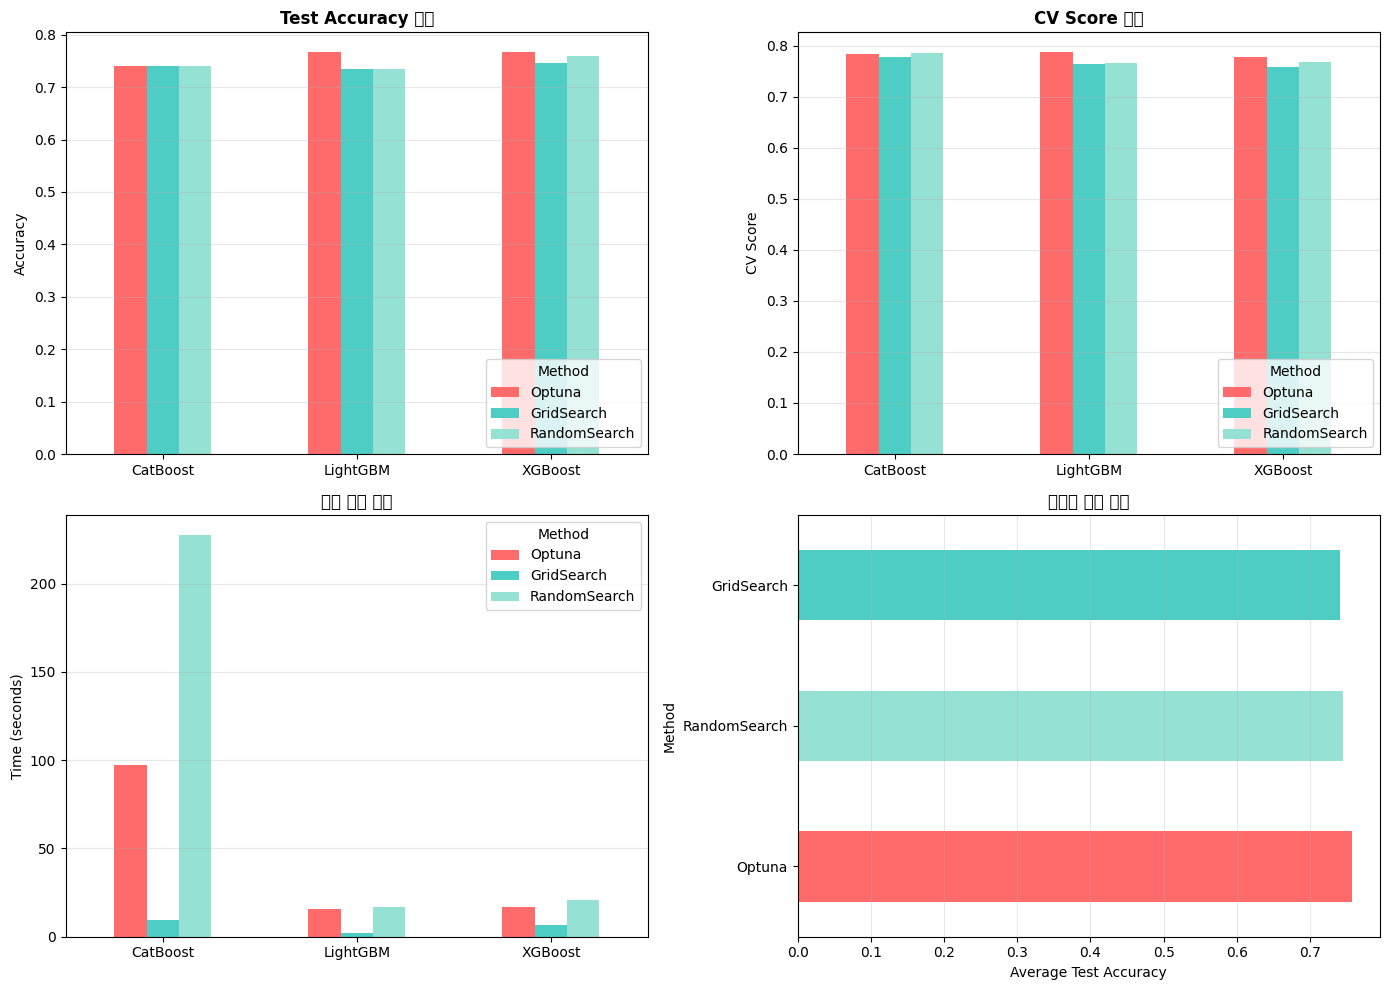

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Test Accuracy 비교
ax1 = axes[0, 0]
pivot_acc = all_results.pivot_table(values='Test Accuracy', index='Model', columns='Method')
pivot_acc[['Optuna', 'GridSearch', 'RandomSearch']].plot(kind='bar', ax=ax1,
                                                           color=['#FF6B6B', '#4ECDC4', '#95E1D3'])
ax1.set_title('Test Accuracy 비교', fontsize=12, fontweight='bold')
ax1.set_ylabel('Accuracy')
ax1.set_xlabel('')
ax1.legend(title='Method', loc='lower right')
ax1.grid(axis='y', alpha=0.3)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0)

# 2. CV Score 비교
ax2 = axes[0, 1]
pivot_cv = all_results.pivot_table(values='CV Score', index='Model', columns='Method')
pivot_cv[['Optuna', 'GridSearch', 'RandomSearch']].plot(kind='bar', ax=ax2,
                                                          color=['#FF6B6B', '#4ECDC4', '#95E1D3'])
ax2.set_title('CV Score 비교', fontsize=12, fontweight='bold')
ax2.set_ylabel('CV Score')
ax2.set_xlabel('')
ax2.legend(title='Method', loc='lower right')
ax2.grid(axis='y', alpha=0.3)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0)

# 3. 시간 비교
ax3 = axes[1, 0]
pivot_time = all_results.pivot_table(values='Time', index='Model', columns='Method')
pivot_time[['Optuna', 'GridSearch', 'RandomSearch']].plot(kind='bar', ax=ax3,
                                                            color=['#FF6B6B', '#4ECDC4', '#95E1D3'])
ax3.set_title('탐색 시간 비교', fontsize=12, fontweight='bold')
ax3.set_ylabel('Time (seconds)')
ax3.set_xlabel('')
ax3.legend(title='Method')
ax3.grid(axis='y', alpha=0.3)
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=0)

# 4. 방법별 평균 성능
ax4 = axes[1, 1]
method_avg_acc = all_results.groupby('Method')['Test Accuracy'].mean().sort_values(ascending=False)
colors_avg = ['#FF6B6B', '#95E1D3', '#4ECDC4']
method_avg_acc.plot(kind='barh', ax=ax4, color=colors_avg)
ax4.set_xlabel('Average Test Accuracy')
ax4.set_title('방법별 평균 성능', fontweight='bold')
ax4.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()